In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [4]:
df=pd.read_csv('banking_loan_dataset.csv')

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Previous_Loan,Credit_Score,Credit_History,Property_Area,Loan_Status
0,LP000001,NaN,Yes,0,Graduate,No,86542,29883,494.0,360.0,0,695,1.0,Urban,Y
1,LP000002,Female,Yes,0,Not Graduate,No,72226,37534,420.0,360.0,0,577,1.0,Urban,Y
2,LP000003,Male,No,3+,Graduate,No,71611,0,458.0,84.0,1,828,1.0,Semiurban,Y
3,LP000004,Male,No,0,Graduate,No,36065,0,624.0,360.0,1,562,0.0,Semiurban,N
4,LP000005,Male,No,0,Graduate,No,24384,0,676.0,360.0,0,879,1.0,Urban,Y


In [7]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Previous_Loan', 'Credit_Score', 'Credit_History',
       'Property_Area', 'Loan_Status'],
      dtype='str')

In [10]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married              59
Dependents           52
Education             0
Self_Employed        47
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           38
Loan_Amount_Term     42
Previous_Loan         0
Credit_Score          0
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].median())

In [8]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Previous_Loan        0
Credit_Score         0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\dell8\AppData\Local\Temp\ipykernel_14116\4134231849.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, accuracy_score(y_test, pred))

C:\Users\dell8\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression 0.625
Decision Tree 0.66
Random Forest 0.72
SVM 0.615
KNN 0.585


In [9]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [11]:
pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7


In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
11,Credit_Score,0.162304
6,ApplicantIncome,0.139799
0,Loan_ID,0.128555
12,Credit_History,0.128358
8,LoanAmount,0.124516
7,CoapplicantIncome,0.086500
9,Loan_Amount_Term,0.051588
10,Previous_Loan,0.045908
3,Dependents,0.038786
13,Property_Area,0.032365


In [13]:
input_data = pd.DataFrame({
    'Gender':[1],
    'Married':[1],
    'Education':[0],
    'ApplicantIncome':[0],
    'CoapplicantIncome':[1000],
    'LoanAmount':[2000],
    'Credit_History':[1],
    'Property_Area':[0],
    'TotalIncome':[60000]
})

input_data = input_data.reindex(columns=X.columns, fill_value=0)

prediction = best_model.predict(input_data)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


<Axes: xlabel='Loan_Status', ylabel='count'>

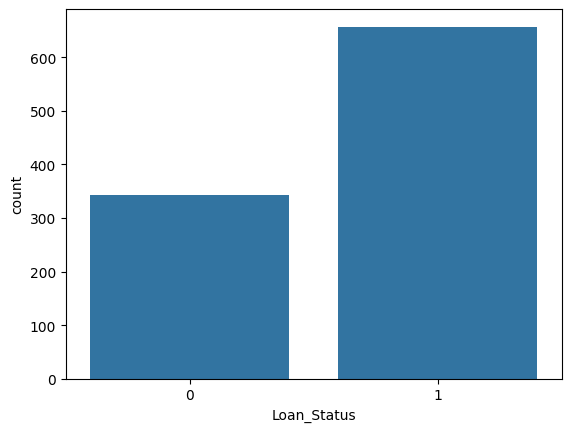

In [21]:
sns.countplot(x="Loan_Status", data=df)

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

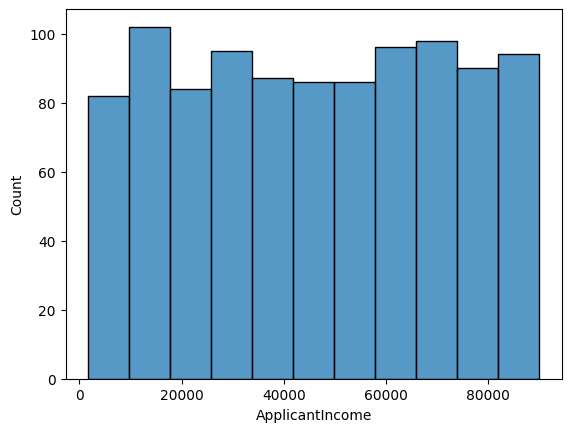

In [22]:
sns.histplot(df["ApplicantIncome"])

<Axes: >

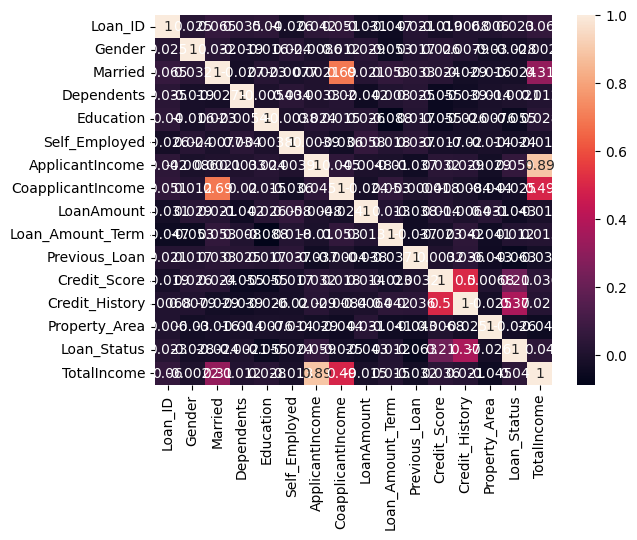

In [23]:
sns.heatmap(df.corr(), annot=True)

In [16]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
print("Model Saved Successfully")

Model Saved Successfully
